In [1]:
# ============================================================
# CELL 0 – ENVIRONMENT SETUP (Colab + Local)
# ============================================================
import os, sys

# 1. Detect if running on Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    PROJECT_ROOT = '/content/hate-speech-detection'
    if not os.path.exists(PROJECT_ROOT):
        os.system('git clone https://github.com/thong7d/hate-speech-detection.git ' + PROJECT_ROOT)
else:
    # Local-first logic: detect root even if running from root folder
    cwd = os.getcwd()
    if os.path.basename(cwd) == 'notebooks':
        PROJECT_ROOT = os.path.abspath(os.path.join(cwd, '..'))
    else:
        PROJECT_ROOT = cwd

# 2. Add src/ to Python path
SRC_PATH = os.path.join(PROJECT_ROOT, 'src')
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

print(f'✅ Environment ready. PROJECT_ROOT: {PROJECT_ROOT}')
REPO_PATH = PROJECT_ROOT

✅ Environment ready. PROJECT_ROOT: /content/hate-speech-detection


FileNotFoundError: [Errno 2] No such file or directory: '/content/hate-speech-detection/results/label_distribution.png'

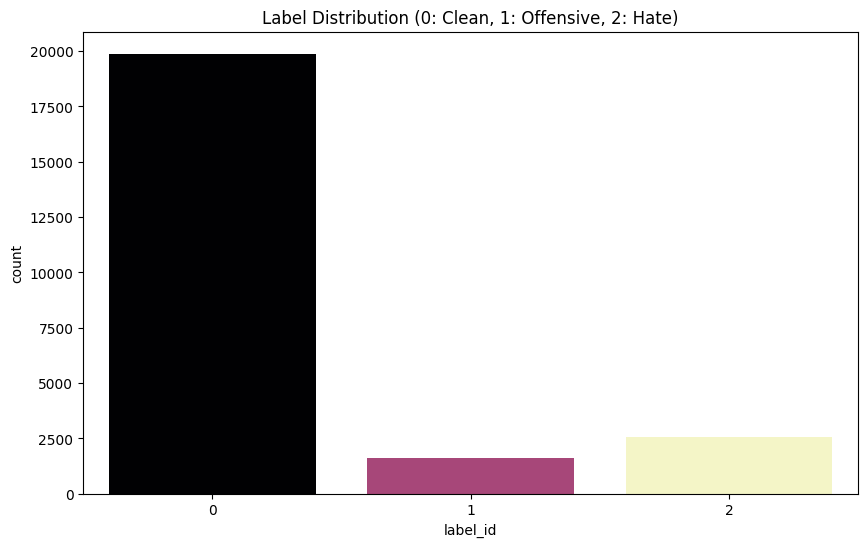

In [2]:
# ============================================================
# CELL 1 – LOAD DATA AND CONFIG
# ============================================================
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load paths from config
with open(f"{REPO_PATH}/configs/paths.yaml", 'r') as f:
    paths = yaml.safe_load(f)

# Path setup (Lưu ý: Bạn cần đảm bảo paths.yaml trỏ đúng vào data/raw/vihsd/)
train_path = os.path.join(PROJECT_ROOT, "data/raw/vihsd/train.csv")
train_df = pd.read_csv(train_path)

# 1. Label Distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='label_id', data=train_df, hue='label_id', palette='magma', legend=False)
plt.title('Label Distribution (0: Clean, 1: Offensive, 2: Hate)')
plt.savefig(f"{PROJECT_ROOT}/results/label_distribution.png")
plt.show()

# 2. Text Length Analysis (To decide max_length for Phase 5)
train_df['text_len'] = train_df['free_text'].fillna('').apply(lambda x: len(x.split()))
p95 = np.percentile(train_df['text_len'], 95)

plt.figure(figsize=(10, 6))
sns.histplot(train_df['text_len'], bins=50, kde=True)
plt.axvline(p95, color='r', linestyle='--', label=f'95th Percentile: {int(p95)}')
plt.title('Word Count Distribution')
plt.legend()
plt.savefig(f"{PROJECT_ROOT}/results/text_length_dist.png")
plt.show()

print(f"Decision: Recommended max_length is {int(p95)} words.")